# Phase 4 — ML Modeling: XGBoost + SHAP + Country Clustering

**Goal:** Go beyond regression — use ML to capture non-linear effects, rank feature importance with SHAP, and cluster countries into staffing-outcome archetypes.

Steps:
1. XGBoost to predict AMI mortality (best outcome variable for ML)
2. SHAP values to explain which variables drive predictions most
3. K-Means clustering to group countries by staffing + outcome profile
4. Export cluster assignments for Power BI map

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed/'
OUTPUTS = '../data/outputs/'
FIGURES = '../figures/'

df = pd.read_csv(PROCESSED + 'master_dataset.csv')
print('Shape:', df.shape)

Shape: (864, 14)


## 1. Prepare Features

In [2]:
FEATURES = ['nurses_per_10k', 'nurse_change_rate', 'gdp_per_capita', 'health_exp_pct_gdp', 'beds_per_1000', 'year']
TARGET = 'mortality_ami_30d'

ml_df = df.dropna(subset=FEATURES + [TARGET])
X = ml_df[FEATURES]
y = ml_df[TARGET]
print(f'Training set: {X.shape[0]} rows')

Training set: 292 rows


## 2. XGBoost — Train & Cross-Validate

In [3]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f'Cross-validated R² scores: {cv_scores.round(3)}')
print(f'Mean R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

model.fit(X, y)

Cross-validated R² scores: [-1.097 -0.3    0.451 -0.041 -5.377]
Mean R²: -1.273 ± 2.113


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

## 3. SHAP — Feature Importance

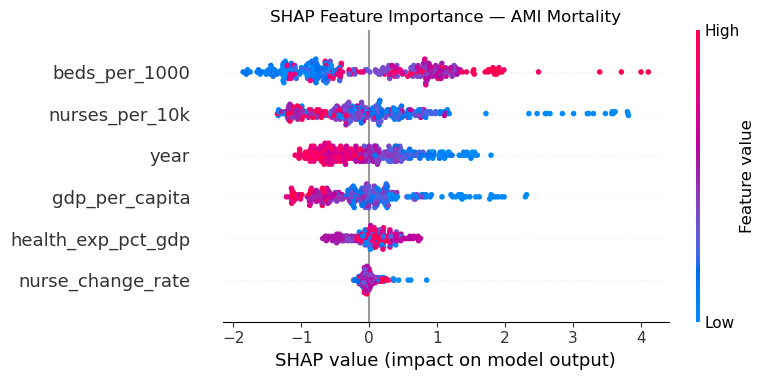

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Feature Importance — AMI Mortality')
plt.tight_layout()
plt.savefig(FIGURES + 'shap_summary.png', bbox_inches='tight')
plt.show()

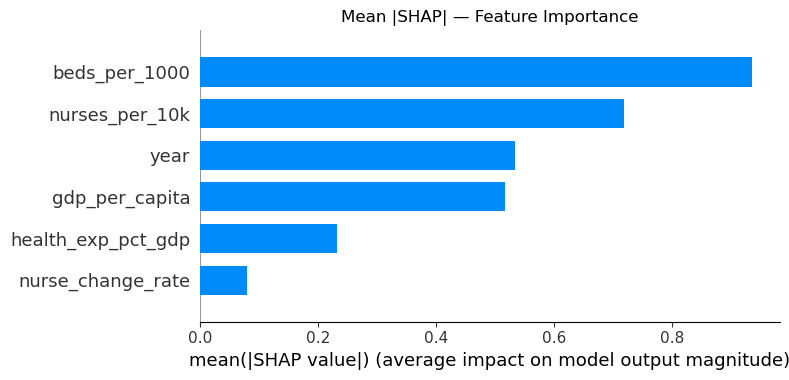

In [5]:
plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('Mean |SHAP| — Feature Importance')
plt.tight_layout()
plt.savefig(FIGURES + 'shap_bar.png', bbox_inches='tight')
plt.show()

## 4. Country Clustering (K-Means)

In [6]:
CLUSTER_FEATURES = ['nurses_per_10k', 'mortality_ami_30d', 'mortality_stroke_30d', 'avg_length_of_stay', 'gdp_per_capita']
cluster_df = df.groupby('country')[CLUSTER_FEATURES].mean().dropna()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

# Find optimal k
sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores.append((k, silhouette_score(X_cluster, labels)))

sil_df = pd.DataFrame(sil_scores, columns=['k', 'silhouette'])
print(sil_df)
best_k = sil_df.loc[sil_df['silhouette'].idxmax(), 'k']
print(f'Best k: {int(best_k)}')

   k  silhouette
0  2    0.283322
1  3    0.285029
2  4    0.288507
3  5    0.297825
4  6    0.294342
Best k: 5


In [7]:
km_final = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_cluster)

print(cluster_df['cluster'].value_counts())
print('\nCluster means:')
print(cluster_df.groupby('cluster')[CLUSTER_FEATURES].mean().round(2))

cluster_df[['cluster']].reset_index().to_csv(OUTPUTS + 'cluster_assignments.csv', index=False)
print('\nSaved cluster_assignments.csv')

cluster
3    8
1    5
2    5
0    4
4    1
Name: count, dtype: int64

Cluster means:
         nurses_per_10k  mortality_ami_30d  mortality_stroke_30d  \
cluster                                                            
0                 61.06              11.80                 14.81   
1                127.82               6.19                  7.88   
2                113.84               8.35                  8.94   
3                 68.63               7.57                 10.08   
4                 81.10               7.14                 24.26   

         avg_length_of_stay  gdp_per_capita  
cluster                                      
0                      8.61        12182.59  
1                      6.42        59912.75  
2                     10.27        62006.77  
3                      7.80        29988.32  
4                      9.81        18804.90  

Saved cluster_assignments.csv


## 5. Cluster Visualisation

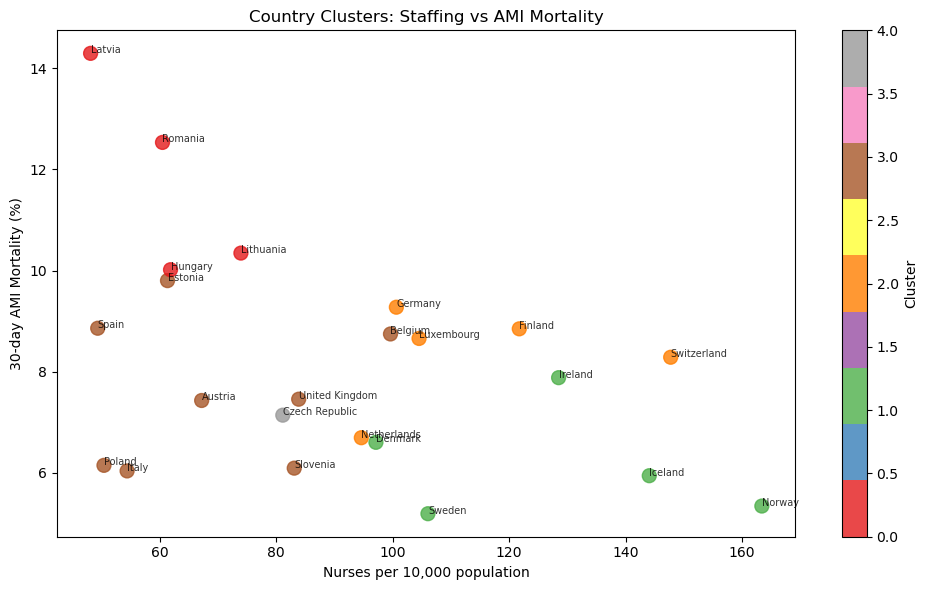

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(cluster_df['nurses_per_10k'], cluster_df['mortality_ami_30d'], c=cluster_df['cluster'], cmap='Set1', s=100, alpha=0.8)

for country, row in cluster_df.iterrows():
    ax.annotate(country, (row['nurses_per_10k'], row['mortality_ami_30d']), fontsize=7, alpha=0.8)

ax.set_xlabel('Nurses per 10,000 population')
ax.set_ylabel('30-day AMI Mortality (%)')
ax.set_title('Country Clusters: Staffing vs AMI Mortality')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(FIGURES + 'country_clusters.png')
plt.show()